In [51]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [52]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [53]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [132]:
def train_model(X, Y, rf=None, sample_weight = None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",
            n_jobs=-1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=1000, eval_metric="rmse"
        )
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    else:
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        if df_paths.shape[1] == 1:
            cand_pe = position_encoder(df_paths, type="onehot")
        else:
            cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf_action, rf_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime_action)
    df_paths_value = np.asarray(df_paths.iloc[:,-1]).reshape(-1,1)
    # print(df_paths,df_paths_value)
    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now+t_prime_action ,t_prime_value)
    rewards_matrix = preds_action[:, 1:]
    # print(preds_value.shape)
    rewards_matrix = np.hstack([rewards_matrix,preds_value])
    discounts = gamma ** np.arange(0, t_prime_action+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    
    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, rewards_matrix

def run_inference(rf_action, rf_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(rf_action, rf_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma,normalization=True)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return pregret,preds


In [149]:
T = 200
gamma = 0.9
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 400
PREGRETS = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards
    # is_pos = (Y_train_value > threshold).astype(int)
    # pos = is_pos.sum()
    # neg = len(Y_train_value) - pos
    # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
    rf_value = train_model(X_train, Y_train_value)
    print(Y_train_value.shape)
    
    PREGRET = []
    current_state = states[T,0]
    for delta_t in range(1,DELTA_T+1):
        next_state, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, T+delta_t, t_prime_action, t_prime_value, gamma)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        ## PolicyIteration
        X_train = np.vstack([X_train, next_features])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

        ## Offline
        # X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        # Y_train_action = irewards[:T+delta_t]

        rf_action = train_model(X_train, Y_train_action, rf_action)

        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = T+delta_t,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value)
        
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val,pred = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS.append(PREGRET)


(200,)
rep 0, T_train 201, pregret=0.2700
rep 0, T_train 202, pregret=0.0245
rep 0, T_train 203, pregret=0.0000
rep 0, T_train 204, pregret=0.0046
rep 0, T_train 205, pregret=0.0199
rep 0, T_train 206, pregret=0.0046
rep 0, T_train 207, pregret=0.0000
rep 0, T_train 208, pregret=0.0054
rep 0, T_train 209, pregret=0.0053
rep 0, T_train 210, pregret=0.0000
rep 0, T_train 211, pregret=0.0369
rep 0, T_train 212, pregret=0.0226
rep 0, T_train 213, pregret=0.0224
rep 0, T_train 214, pregret=0.0222
rep 0, T_train 215, pregret=0.0173
rep 0, T_train 216, pregret=0.0359
rep 0, T_train 217, pregret=0.0322
rep 0, T_train 218, pregret=0.0304
rep 0, T_train 219, pregret=0.0213
rep 0, T_train 220, pregret=0.0048
rep 0, T_train 221, pregret=0.0000
rep 0, T_train 222, pregret=0.0048
rep 0, T_train 223, pregret=0.0000
rep 0, T_train 224, pregret=0.0000
rep 0, T_train 225, pregret=0.0048
rep 0, T_train 226, pregret=0.0048
rep 0, T_train 227, pregret=0.0047
rep 0, T_train 228, pregret=0.0047
rep 0, T_trai

In [154]:
np.unique(pred[:,-1])

array([ 9.87945557, 14.37007141, 16.97374535, 17.73788834, 17.74166679,
       17.79142952, 18.11308479])

In [158]:
T = 200
gamma = 0.9
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 400
PREGRETS_random = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards
    # is_pos = (Y_train_value > threshold).astype(int)
    # pos = is_pos.sum()
    # neg = len(Y_train_value) - pos
    # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
    rf_value = train_model(X_train, Y_train_value)
    print(Y_train_value.shape)
    
    PREGRET = []
    current_state = states[T,0]
    for delta_t in range(1,DELTA_T+1):
        next_state, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, T+delta_t, t_prime_action, t_prime_value, gamma)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        ## PolicyIteration
        # X_train = np.vstack([X_train, next_features])
        # Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

        ## Offline
        X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        Y_train_action = irewards[:T+delta_t]

        rf_action = train_model(X_train, Y_train_action, rf_action)

        Y_train_value = make_weighted_target(Y_train_action, gamma,T = T+delta_t,normalization = False)
        is_pos = (Y_train_value > threshold).astype(int)
        pos = is_pos.sum()
        neg = len(Y_train_value) - pos
        w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value, sample_weight=w)
        
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val,pred = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS_random.append(PREGRET)


(200,)
(201, 57) (201,) (201,)
rep 0, T_train 201, pregret=0.0246
(202, 57) (202,) (202,)
rep 0, T_train 202, pregret=0.2693
(203, 57) (203,) (203,)
rep 0, T_train 203, pregret=0.0244
(204, 57) (204,) (204,)
rep 0, T_train 204, pregret=0.0243
(205, 57) (205,) (205,)
rep 0, T_train 205, pregret=0.0242
(206, 57) (206,) (206,)
rep 0, T_train 206, pregret=0.0240
(207, 57) (207,) (207,)
rep 0, T_train 207, pregret=0.0239
(208, 57) (208,) (208,)
rep 0, T_train 208, pregret=0.0237
(209, 57) (209,) (209,)
rep 0, T_train 209, pregret=0.0235
(210, 57) (210,) (210,)
rep 0, T_train 210, pregret=0.2652
(211, 57) (211,) (211,)
rep 0, T_train 211, pregret=0.0277
(212, 57) (212,) (212,)
rep 0, T_train 212, pregret=0.0228
(213, 57) (213,) (213,)
rep 0, T_train 213, pregret=0.0271
(214, 57) (214,) (214,)
rep 0, T_train 214, pregret=0.0222
(215, 57) (215,) (215,)
rep 0, T_train 215, pregret=0.0218
(216, 57) (216,) (216,)
rep 0, T_train 216, pregret=0.0355
(217, 57) (217,) (217,)
rep 0, T_train 217, pregr

In [159]:
# PREGRETS_arr = np.vstack(PREGRETS)
PREGRETS_random_arr = np.vstack(PREGRETS_random)
np.savez(
    f"../results/OnlinePAFM/PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead{6}_10reps.npz",
    pregrets_online = PREGRETS_arr,
    pregrets_offline = PREGRETS_random_arr
    )
    



[[0.66921283 0.80930889 0.3922477  ... 0.         0.         0.        ]
 [1.33086777 1.33064961 1.13970004 ... 0.         0.         0.        ]
 [1.18735611 1.33799328 1.18203661 ... 0.         0.         0.        ]
 ...
 [1.0583818  1.10518635 1.10479226 ... 0.         0.         0.        ]
 [1.21797087 1.06590272 1.05134186 ... 0.         0.         0.        ]
 [0.97880772 0.96571597 0.95861994 ... 0.         0.         0.        ]]


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/1308894777.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PuRd')


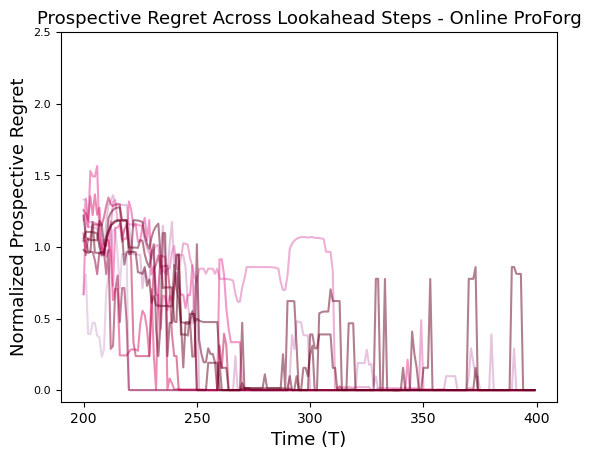

In [136]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_oh_w_time200_400_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_VA_arr = 0.5*data["pregrets_online"]
print(PREGRETS_VA_arr)

cmap = cm.get_cmap('PuRd')
fontsize = 13
cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
for i in range(10):
    plt.plot(np.arange(200,400),PREGRETS_VA_arr[i],alpha = 0.5,color = cmap_color[i])
plt.xticks([200,250,300,350,400])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)
plt.show()



In [169]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_arr = data["pregrets_online"]
PREGRETS_random_arr = data["pregrets_offline"]
print(PREGRETS_arr)



fn = f"../results/OnlinePAFM/GBT_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_PAFM_arr = data["pregrets_online"]
PREGRETS_random_PAFM_arr = data["pregrets_offline"]
print(PREGRETS_PAFM_arr)

# cmap = cm.get_cmap('PuRd')
# fontsize = 13
# cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
# for i in range(5):
#     plt.plot(np.arange(200,600),PREGRETS_arr[i],alpha = 0.5,color = cmap_color[i])
# plt.xticks([200,250,300,350,400])
# plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
# plt.xlabel("Time (T)",fontsize = fontsize)
# plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# # plt.xscale('log')
# plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)
# plt.show()

[[0.26996331 0.02450598 0.         ... 0.00982435 0.00970222 0.00958946]
 [0.77851861 0.76947402 0.82641943 ... 0.         0.         0.        ]
 [1.09342528 1.10993587 1.09159596 ... 0.01225851 0.01188842 0.01150015]
 ...
 [0.80226315 0.81083367 0.82628898 ... 0.00542893 0.00533707 0.0052579 ]
 [0.91176296 0.92530537 0.88971203 ... 0.00982435 0.00970222 0.00958946]
 [0.47590737 0.47173301 0.55803146 ... 0.         0.         0.        ]]
[[1.32925824 1.02361377 0.95509526 ... 0.         0.         0.        ]
 [1.18778069 1.18734909 1.18680692 ... 0.         0.         0.        ]
 [1.16872431 1.15585551 1.15531774 ... 0.         0.         0.        ]
 [1.10732681 1.16443127 1.05856363 ... 0.         0.         0.        ]
 [1.1278969  1.17326312 1.1885336  ... 0.71622535 0.47678795 0.23837353]]


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/3696504255.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('OrRd')


Text(0.5, 1.0, 'Prospective Regret Across Lookahead Steps - Online ProForg')

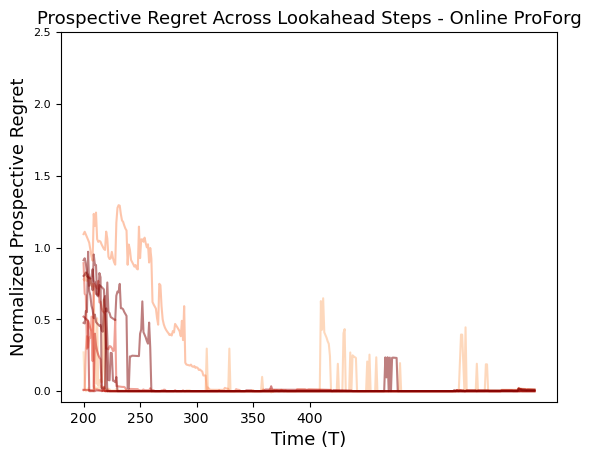

In [156]:
cmap = cm.get_cmap('OrRd')
fontsize = 13
cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
for i in range(10):
    plt.plot(np.arange(200,600),PREGRETS_arr[i],alpha = 0.5,color = cmap_color[i])
plt.xticks([200,250,300,350,400])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)
# plt.show()
# cmap = cm.get_cmap('PuRd')
# fontsize = 13
# cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
# for i in range(10):
#     plt.plot(np.arange(200,250),PREGRETS_arr_2[i,:50],alpha = 0.5,color = cmap_color[i])
# plt.xticks([200,250,300,350,400])
# plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
# plt.xlabel("Time (T)",fontsize = fontsize)
# plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# # plt.xscale('log')
# plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/1156253438.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


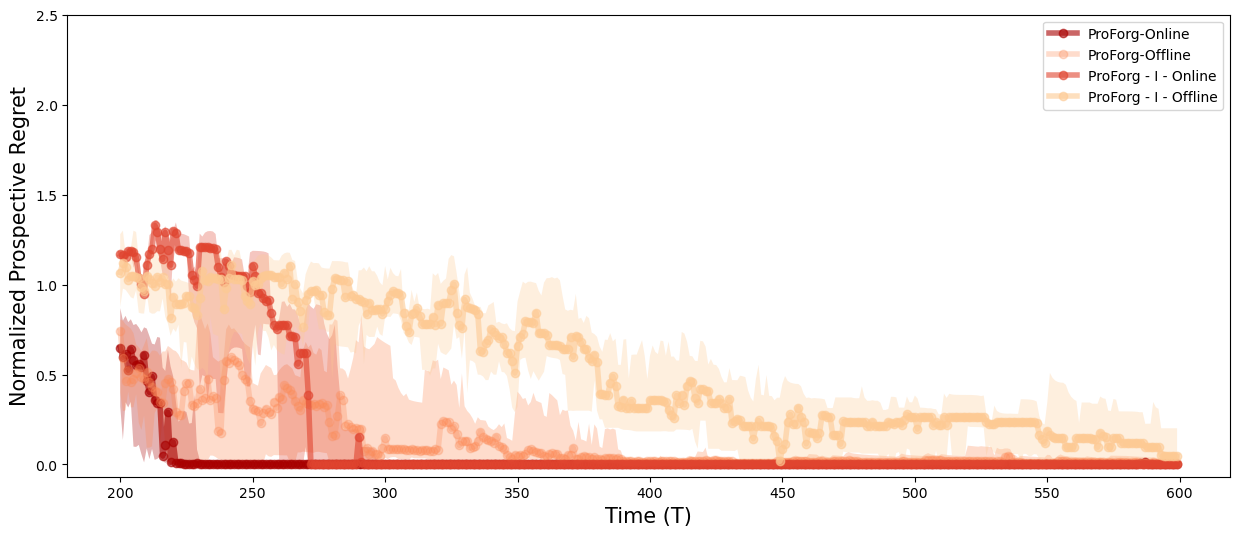

In [178]:

def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

plt.figure(figsize=(15, 6))

linewidth = 4
fontsize = 15
pafm_df_offline, pvafm_df_offline, pafm_df_online,pvafm_df_online= get_close_colors("OrRd", start = 0.3, delta = 0.2 , n = 4) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_RF_offline":pafm_df_offline,
          "PAFM_RF_online": pafm_df_online,
          "PVAFM_RF_online":pvafm_df_online,
           "PVAFM_RF_offline":pvafm_df_offline,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI":rl_fqi,
          "RL_TQL":rl_tql
          }

Ts_online = np.arange(200,600,1)
PREGRETS_arr = PREGRETS_arr
median = np.median(PREGRETS_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PVAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg-Online')
plt.fill_between(Ts_online, q25, q75, color=colors["PVAFM_RF_online"], alpha=0.30, edgecolor="none")


PREGRETS_random_arr = PREGRETS_random_arr
median = np.median(PREGRETS_random_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PVAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg-Offline')
plt.fill_between(Ts_online, q25, q75, color=colors["PVAFM_RF_offline"], alpha=0.30, edgecolor="none")


Ts_online = np.arange(200,600,1)
median = np.median(PREGRETS_PAFM_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg - I - Online')
plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_online"], alpha=0.30, edgecolor="none")

median = np.median(PREGRETS_random_PAFM_arr, axis=0)   
# q25 = median  - np.std(PREGRETS_random_PAFM_arr, axis=0)   
# q75  = median  + np.std(PREGRETS_random_PAFM_arr, axis=0) 
q25  = np.nanpercentile(PREGRETS_random_PAFM_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_PAFM_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg - I - Offline')
plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_offline"], alpha=0.30, edgecolor="none")




# median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
# plt.plot(Ts_DF, median,color=colors["PAFM_RF"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - offline')
# plt.fill_between(Ts_DF, q25, q75, color=colors["PAFM_RF"], alpha=0.20, edgecolor="none")


# xticks = Ts_online + Ts_DF
# xticklabels = [str(v) if v in [128,256,512] else "" 
#                for i, v in enumerate(xticks)]

# plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.xticks([200,250,300,350,400,450,500,550,600])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.title('Prospective Regret Across Lookahead Steps - Online vs Offline',fontsize = fontsize)
plt.legend()